# Análisis Exploratorio de Datos (EDA)


Para obtener el conjunto de datos completo de las estadísticas en el sector agrícola fueron descargados los datasets correspondientes desde el año 2010 hasta el 2014. Para trabajar con la información completa se concatenaron todos estos datos.

Es importante mencionar que durante la concatenación de estos datos, algunos años cambiaban el nombre de las columnas, como por ejemplo Precio que llego a registrarse como Preciomediorural. Para esto se unificaron estos nombres, que representan la misma información pero el sistema manejaba terminologías distintas.

In [1]:
#| echo: false
#| output: false
import sys
sys.path.insert(0, '..')

from src.data_loader import DataLoader
from src.eda import EDAAnalyzer

RUTA_CSV = '../data/raw/siap_2010_2024.csv'

loader = DataLoader(RUTA_CSV)
df = loader.cargar()

[DataLoader] Cargando siap_2010_2024.csv ...
[DataLoader] 541839 filas , 24 columnas cargadas.


## Descripción general

El conjunto de datos que se utiliza en este proyecto consiste de 541,839 filas correspondientes a cada registro a nivel municipal. Cada registro cuenta con 24 columnas que describen los detalles del mismo, estas son variables categóricas y numéricas.

In [2]:
#| echo: false
eda = EDAAnalyzer(df, guardar_figuras=True)
resumen = eda.descripcion_general()

DESCRIPCIÓN DEL DATASET

Filas    : 541839
Columnas : 24
Periodo  : 2010 – 2024



,Tipo de Dato,No Nulos,Únicos
Anio,Int64,541839,15
Idestado,int64,541839,32
Nomestado,category,541839,33
Idddr,int64,541839,191
Nomddr,str,541839,191
Idcader,int64,541839,19
Nomcader,str,541839,678
Idmunicipio,int64,541839,570
Nommunicipio,str,541839,2312
Idciclo,int64,541839,3


### Variable Derivada: Proporción de Siniestro

A partir de la información obtenida a través del dataset resulta conveniente la creación de una nueva variable: Proporción de Siniestro. Esto debido a que la columna Siniestrada registra las hectáreas de la superficie de la cual no se obtuvo cultivo debido a alguna causa de fuerza mayor como lo es el impacto del cambio climático. Sin embargo, podemos diferenciar en que perder 500 hectáreas en un municipio que sembró 600 representa una catástrofe agrícola, mientras que la misma cifra en un municipio que sembó 50,000 hectáreas constituye una pérdida marginal.

Por ello, este ratio nos permite tener más consistencia de análisis y dimensionar mejor. El rango va de 0 (sin pérdida) a 1 (la totalidad del área sembrada fue siniestrada). La definición de la variable es:

$$proporcion\_siniestro = \frac{Siniestrada}{Sembrada}$$

In [3]:
#| echo: false
df = eda.nueva_variable_proporcion_siniestro()

,Tipo de Dato,No Nulos,Únicos
0,float64,541839,13328


Como resultado obtenemos la asignación de esta nueva variable para los registros, tenemos asignada esta proporción para los 541,839 datos.

## Calidad de datos

A continuación vamos a analizar los valores faltantes en el dataset y la presencia de registros duplicados.

In [4]:
#| echo: false
metricas_calidad = eda.calidad_datos()

,Nulos,% Nulos
Precio,487,0.09
Rendimiento,487,0.09
Volumenproduccion,1,0.00
Sembrada,2,0.00



Registros duplicados: 10


Podemos observar que la calidad de los datos proporcionados por la Dirección General del Sistema de Información Agroalimentaria y Pesquera es consistente. La presencia de datos nulos para Precio y Rendimiento se encuentra en solo 487 registros, lo que representa un 0.09% de nuestro conjunto de datos. Estos registros son una pequeña proporción, dado que contamos con más de 500,000 datos resulta muy pequeña la cantidad de nulos.

Por otro lado, Volumenproduccion y Sembrada en conjunto presentan nulos en tan solo 3 registros, lo cual no afecta en la potencia estadística.

### Valores Faltantes

Resulta conveniente adentrarnos en la aparición de valores nulos en ciertos registros. En el siguiente gráfico podemos ver la correlación entre la presencia de nulos de las 4 variables que los presentan: Sembrada, Volumenproduccion, Rendimiento y Precio.

Podemos observar que Rendimiento y Precio están fuertemente relacionadas. En 487 registros, Precio y Rendimiento faltan en conjunto, es decir, cuando falta Precio siempre falta Rendimiento, lo que indica una regla o dependencia estricta. Por otro lado, Sembrada y Volumenproduccion al ser muy pocos pueden ser considerados como errores de captura en el sistema de datos que obtuvimos inicialmente.

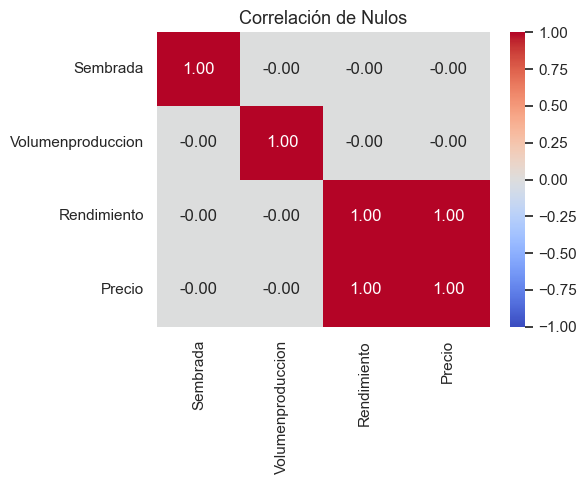

In [5]:
#| echo: false
eda.analisis_nulos()

Adentrandonos más en la falta de los campos Precio y Rendimiento totalmente relacionados, conviene analizar si son un error de captura en el sistema indicando MCAR o si hay algún factor que influye en su ausencia. 

In [6]:
#| echo: false
nulos_precio = df['Precio'].isna()
cosechada_cero = df['Cosechada'] == 0
total_nulos = nulos_precio.sum()

if total_nulos > 0:
    coincidencias = (nulos_precio & cosechada_cero).sum()
    pct = (coincidencias / total_nulos) * 100
                
    print(f"De los {total_nulos:,} registros sin Precio/Rendimiento,")
    print(f"{coincidencias:,} ({pct:.2f}%) tienen Área Cosechada igual a 0.")

De los 487 registros sin Precio/Rendimiento,
487 (100.00%) tienen Área Cosechada igual a 0.


Al filtrar los datos por los registros con nulos en Precio y al compararlo con la columna de Cosechada, observamos que todos los registros que les falta el Precio/Rendimiento presentan un área cosechada de 0.

Si un cultivo se siembra pero hay una sequía o inundación y se pierde todo (Área Cosechada = 0), entonces el Volumen de Producción será 0. Dado que el Rendimiento se calcula dividiendo la producción entre el área cosechada, el valor no existe (se vuelve nulo). Y como no se produjo nada, no hay producto que vender, por lo tanto no se reporta un Precio. En este caso, la falta de datos es estructural y depende del área cosechada/siniestrada (esto lo clasifica como MAR, ya que la ausencia se explica por otra variable observable).

**Deciciones sobre Valores Faltantes**

Con las observaciones anteriores, procedemos con los datos como sigue:

1. Se eliminan los registros que tienen valores nulos en Sembrada y Volumenproduccion, debido a que indican presencia de errores de captura.

2. Para los 487 registros donde falta Precio/Rendimiento, se actualizan los campos correspondientes a 0 (cero), debido a que comprobamos que pudo haber sido error de captura cuando el área cosechada fue 0.

In [7]:
#| echo: false
df = eda.imputar_nulos_estructurales()

### Duplicados

En el total del conjunto de datos se encontraron únicamente 10 registros duplicados. Dado que es un número muy pequeño considerando el tamaño de datos que estamos trabajando, podemos eliminarlos sin afectar la potencia estadística.

In [8]:
#| echo: false
df = eda.eliminar_duplicados()

Se eliminaron 10 registros duplicados.
El dataset ahora tiene 541,829 filas.


Como resultado de esta decisión, ahora el dataset cuenta con 541,829 registros.

## Estadísticas descriptivas

A continuación presentamos las estadísticas descriptivas de nuestro conjunto de datos. Necesitamos analizar tanto nuestras variables numéricas como las categóricas.

### Variables Numéricas

In [9]:
#| echo: false
desc = eda.estadisticas_descriptivas_numericas()

,count,mean,std,min,25%,50%,75%,max,rango
Sembrada,541827.0,580.74,2640.83,0.0,10.00,39.40,216.00,2.165483e+05,2.165483e+05
Cosechada,541829.0,544.29,2535.06,0.0,9.00,35.00,200.00,2.165483e+05,2.165483e+05
Siniestrada,541829.0,24.14,386.67,0.0,0.00,0.00,0.00,5.407300e+04,5.407300e+04
Volumenproduccion,541828.0,16191.87,617977.39,0.0,52.40,292.50,1743.75,1.183000e+08,1.183000e+08
Rendimiento,541829.0,1091.27,62114.13,0.0,2.07,7.91,20.00,1.059804e+07,1.059804e+07
Precio,541829.0,6783.82,11710.66,0.0,2217.22,4298.52,7675.00,2.048000e+06,2.048000e+06
Valorproduccion,541829.0,16176411.05,90348428.14,0.0,246245.25,1084183.48,5443200.00,7.622198e+09,7.622198e+09


El análisis descriptivo de las variables numéricas revela patrones relevantes sobre la estructura productiva y la distribución del riesgo agrícola en México durante el periodo 2010–2024.

**Área sembrada y cosechada** presentan distribuciones muy similares entre sí, lo cual es esperado dado que la mayor parte de lo sembrado logra cosecharse en condiciones normales. Ambas variables tienen una media considerablemente mayor a su mediana (Sembrada: media = 580.7 ha, mediana = 39.4 ha; Cosechada: media = 544.3 ha, mediana = 35.0 ha), lo que indica una distribución fuertemente sesgada hacia la derecha. Esto refleja la coexistencia de pequeños productores con superficies mínimas junto a grandes unidades productivas que elevan la media. El valor máximo de 216,548 ha confirma la presencia de registros de gran escala que actúan como outliers en la distribución.

La media de **Área siniestrada** es de apenas 24.1 ha, pero su desviación estándar es de 386.7 ha, casi 16 veces mayor que la media, lo que evidencia una dispersión extrema. Más revelador aún es que tanto el percentil 25 como el percentil 50 y el percentil 75 son iguales a 0, lo que significa que al menos el 75% de los registros no reportaron ningún siniestro. La pérdida agrícola es entonces un evento infrecuente pero de alta magnitud cuando ocurre, con un máximo registrado de 54,073 ha en un solo registro.

Por otro lado, **Rendimiento** presenta la mayor dispersión relativa de todas las variables, con una desviación estándar de 62,114 sobre una media de 1,091 ton/ha, y un máximo de 10,598,037. Estos valores extremos corresponden probablemente a cultivos con unidades de medida distintas a toneladas por hectárea (como miles de litros para maguey pulquero), por lo que esta variable requiere un filtrado cuidadoso por unidad de medida antes de incluirse en un modelado.

**Precio** y **Valorproduccion** muestran rangos enormes (precio máximo de 2,048,000 pesos por tonelada), consistentes con la diversidad de cultivos registrados, desde granos básicos de bajo valor unitario hasta productos especializados de alto valor. Ambas variables deberán normalizarse antes del modelado y su uso como predictores deberá justificarse, ya que son variables de resultado económico más que variables de contexto productivo.

### Variables Categóricas

In [10]:
#| echo: false
eda.estadisticas_descriptivas_categoricas()


Nomestado: 33 categorías. Moda: 'Oaxaca'
Top 3 frecuencias (conteos):
- Oaxaca: 71,184 registros
- Puebla: 51,753 registros
- Michoacán: 35,188 registros

Nomcicloproductivo: 3 categorías. Moda: 'Primavera-Verano'
Top 3 frecuencias (conteos):
- Primavera-Verano: 234,707 registros
- Perennes: 166,175 registros
- Otoño-Invierno: 140,947 registros

Nommodalidad: 2 categorías. Moda: 'Riego'
Top 3 frecuencias (conteos):
- Riego: 295,546 registros
- Temporal: 246,283 registros

Nomcultivo: 454 categorías. Moda: 'Maíz grano'
Top 3 frecuencias (conteos):
- Maíz grano: 69,586 registros
- Frijol: 43,677 registros
- Avena forrajera en verde: 21,910 registros


**Nomestado** registra 33 categorías con moda en Oaxaca, lo que indica que este estado concentra la mayor cantidad de registros en el dataset. Esto es consistente con su alta diversidad municipal (es el estado con más municipios en México, 570) y con la variedad de cultivos que se producen en su territorio. No implica necesariamente que Oaxaca tenga el mayor volumen productivo, sino que tiene la mayor cantidad de combinaciones únicas de año-municipio-cultivo registradas.

**Nomcicloproductivo** tiene 3 categorías con moda en Primavera-Verano, el ciclo agrícola principal en México. Este ciclo concentra la mayoría de la actividad de temporal, que depende de las lluvias estacionales y es por tanto el más expuesto al riesgo climático. Su predominancia en el dataset es relevante para el análisis de siniestros, ya que las sequías e inundaciones afectan principalmente este ciclo.

**Nommodalidad** presenta únicamente 2 categorías (Riego y Temporal), con moda en Riego. Aunque en la realidad nacional la agricultura de temporal supera en superficie a la de riego, el mayor número de registros bajo modalidad de riego puede explicarse por la mayor diversidad de cultivos que se producen bajo esta modalidad y su distribución en más municipios. Esta variable es una de las más importantes para el análisis de vulnerabilidad, dado que las siembras de temporal son estructuralmente más susceptibles al siniestro por su dependencia de las precipitaciones.

**Nomcultivo** es la variable categórica con mayor cardinalidad, con 454 categorías distintas y moda en Maíz grano. La dominancia del maíz es consistente con su rol como cultivo básico de México: es el de mayor superficie sembrada, el más distribuido geográficamente y el de mayor relevancia para la seguridad alimentaria nacional.

## Detección de valores atípicos

Aplicamos la regla IQR sobre las principales variables numéricas y visualizamos boxplots comparativos por modalidad hídrica (Temporal vs Riego).  
Requisito 4.

  OUTLIERS (Regla IQR)
                Q1     Q3     IQR  Lím. inf.  Lím. sup.  Outliers  % Outliers
Variable                                                                     
Sembrada     10.00  216.0  206.00   -299.000    525.000     86182       15.91
Siniestrada   0.00    0.0    0.00      0.000      0.000     26817        4.95
Rendimiento   2.09   20.0   17.91    -24.775     46.865     48854        9.02

  Decisión: los outliers extremos en Siniestrada y Rendimiento
  corresponden a eventos reales (desastres climáticos), por lo que
  se conservan. Se aplicará transformación log1p antes del modelado.
  Figura guardada: figuras/outliers_boxplot.png


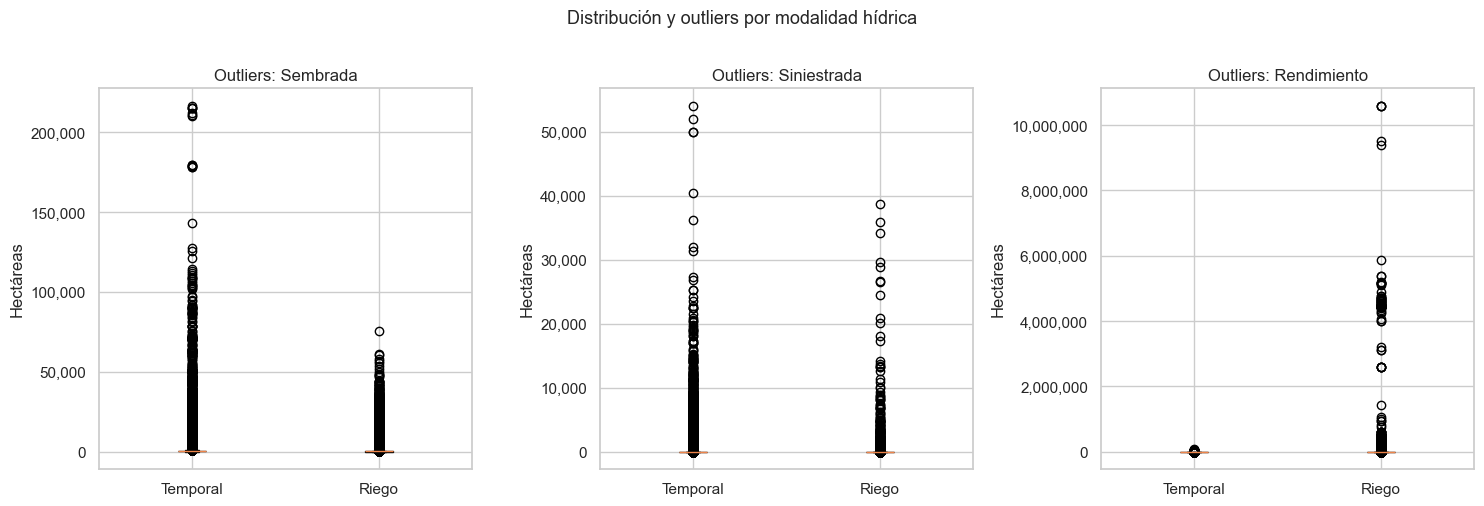

In [5]:
tabla_outliers = eda.detectar_outliers()

**Interpretación:**  
_(¿Qué porcentaje de registros son outliers en cada variable? Los valores extremos de `Siniestrada` probablemente corresponden a estados con sequías severas (p.ej. Sonora, Chihuahua). ¿Se deben eliminar o conservar? Justifica con base en el objetivo del proyecto.)_

## 5. Distribuciones

Histogramas de todas las variables numéricas relevantes.  
Para variables con sesgo positivo severo (skewness > 2) se aplica transformación log1p automáticamente para mejorar la visualización.  
Requisito 5.

  Figura guardada: figuras/distribuciones.png


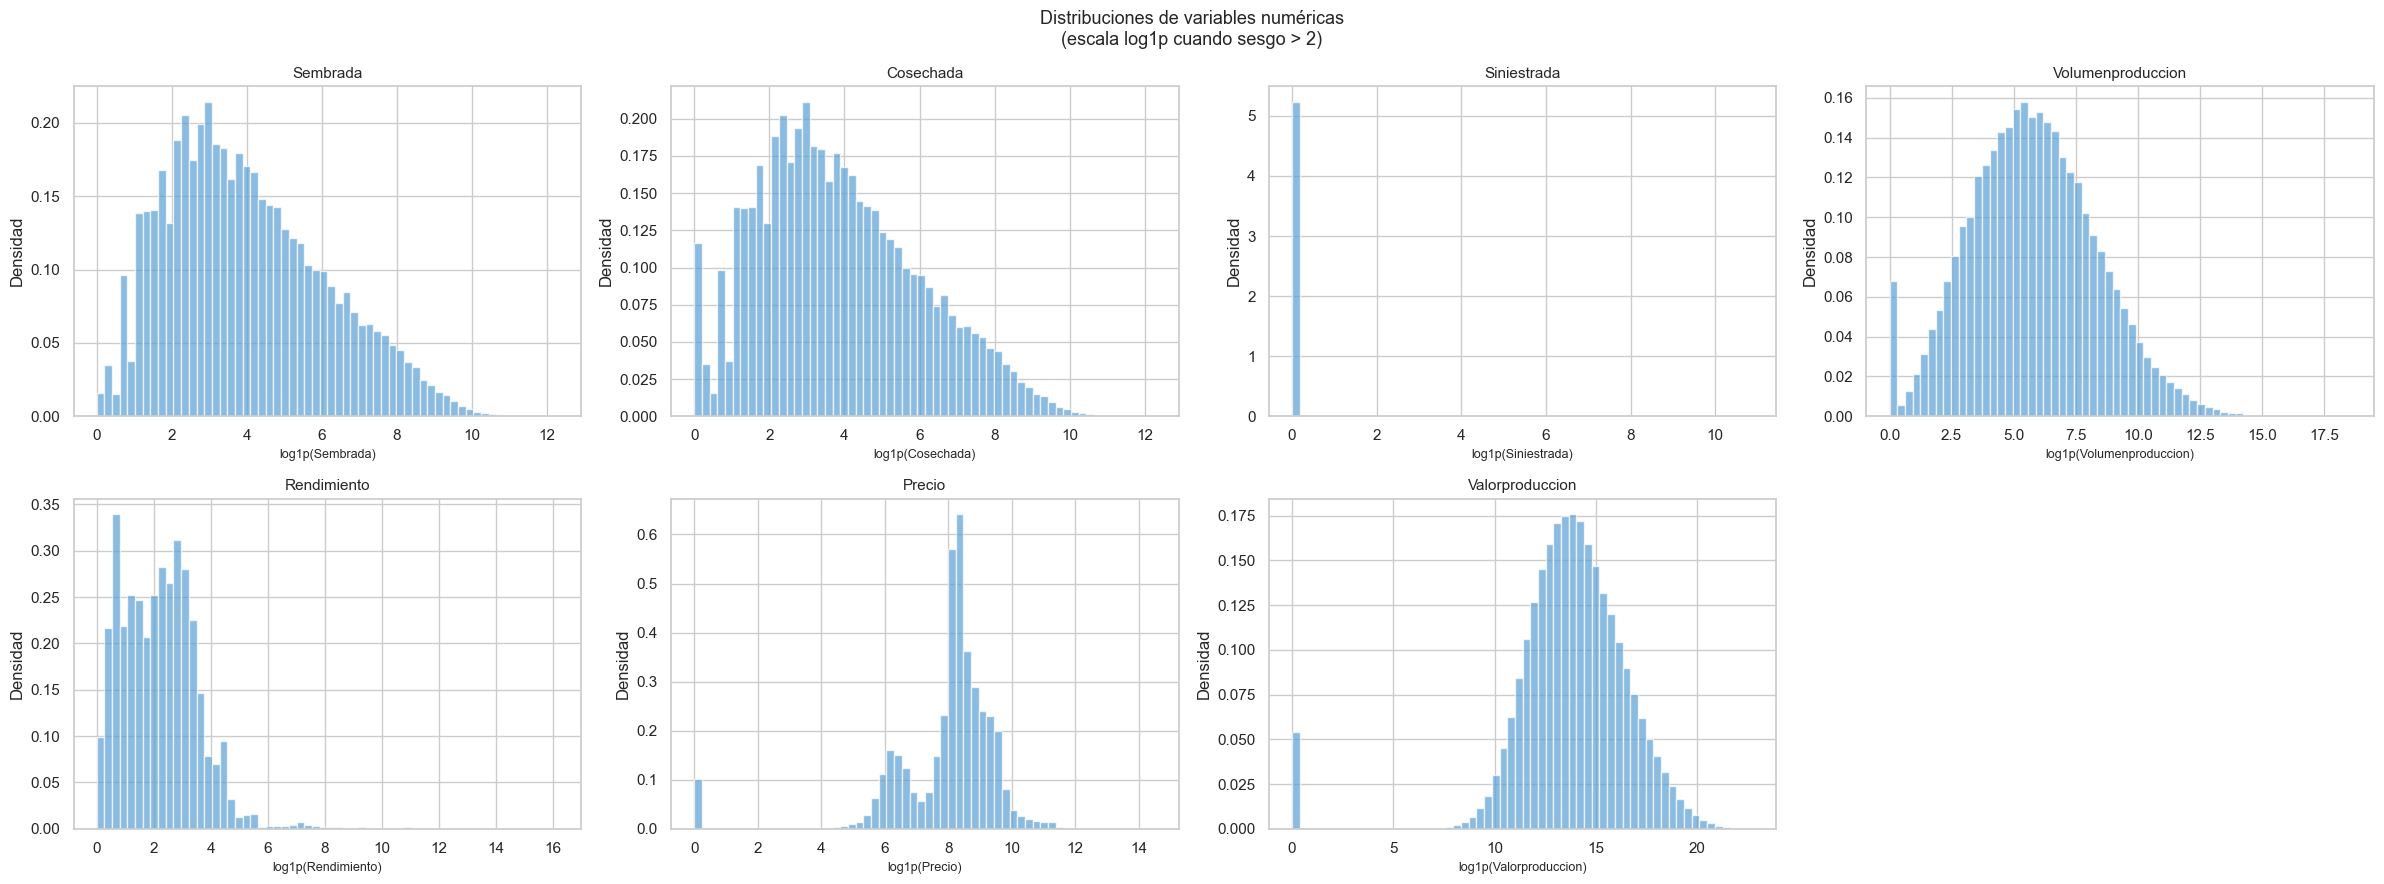

In [6]:
eda.visualizar_distribuciones()

**Interpretación:**  
_(¿Las distribuciones son normales, log-normales o bimodales? La distribución de `Siniestrada` probablemente tenga una masa enorme en 0 (siembras sin siniestro) con una cola larga a la derecha. Esto tiene implicaciones para el modelo: ¿regresión o clasificación binaria?)_

## 6. Relaciones entre variables

Matriz de correlaciones con heatmap (Spearman, robusto a outliers) y scatter plot de las dos variables clave del proyecto.  
Requisito 6.

  Figura guardada: figuras/correlaciones.png


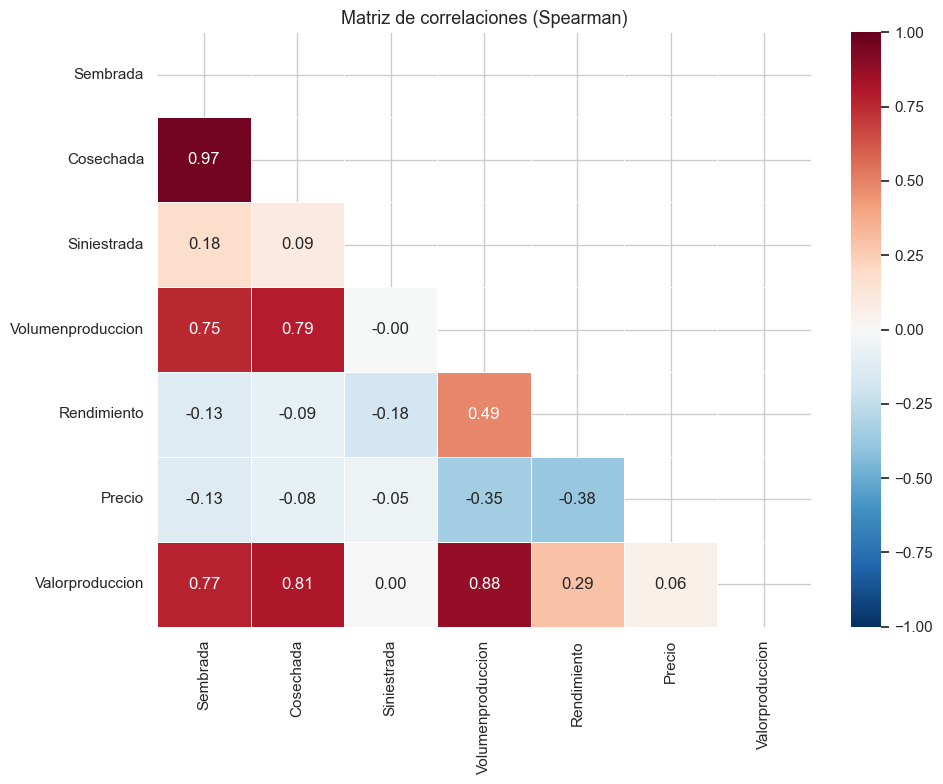


  Correlaciones notables con Siniestrada (spearman):
  · Sembrada: 0.176
  · Rendimiento: -0.184


In [7]:
corr = eda.matriz_correlaciones(metodo='spearman')

  Figura guardada: figuras/scatter_sembrada_siniestrada.png


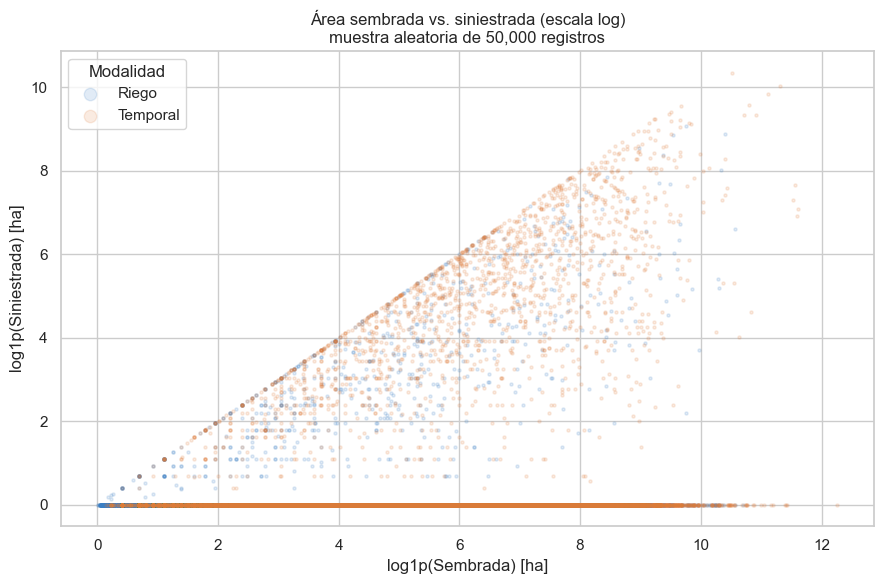

In [8]:
eda.scatter_sembrada_vs_siniestrada()

**Interpretación:**  
_(¿Existe correlación positiva entre `Sembrada` y `Siniestrada`? ¿Es más fuerte en temporal que en riego? ¿Hay multicolinealidad entre variables que deba considerarse antes del modelado?)_

## 7. Análisis de variables categóricas

Gráficas de barras con frecuencias absolutas para las principales variables categóricas.  
Análisis del balance de la variable objetivo (`ratio_siniestro`) por modalidad.  
Requisito 7.

  Figura guardada: figuras/barras_Nomestado.png


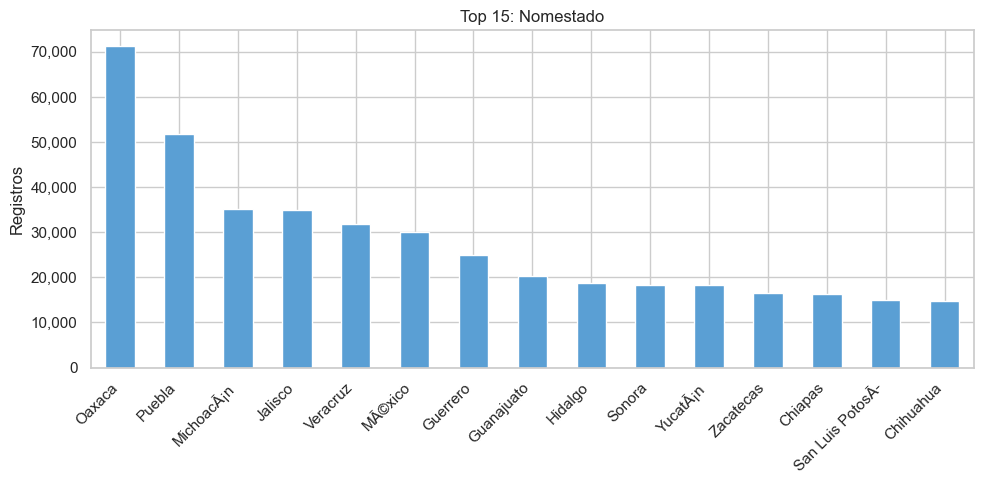

  Figura guardada: figuras/barras_Nomcicloproductivo.png


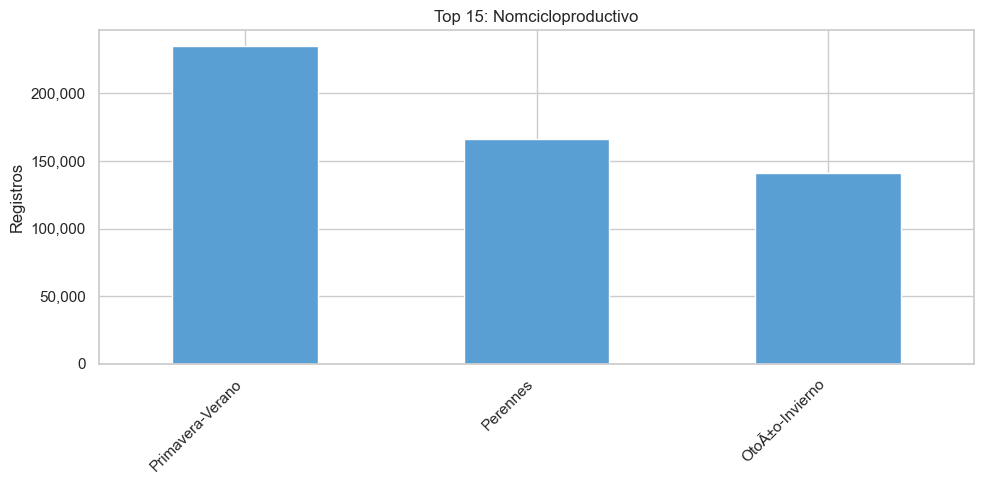

  Figura guardada: figuras/barras_Nommodalidad.png


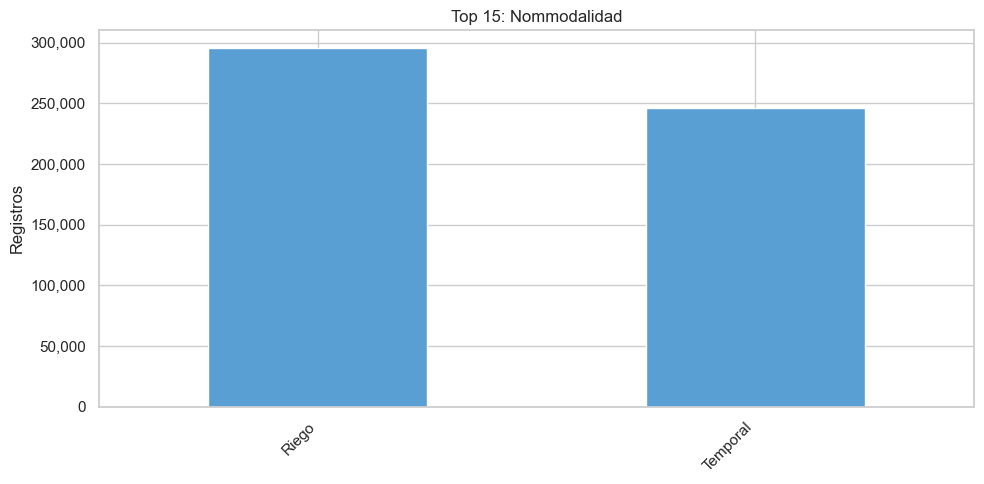

  Figura guardada: figuras/barras_Nomcultivo.png


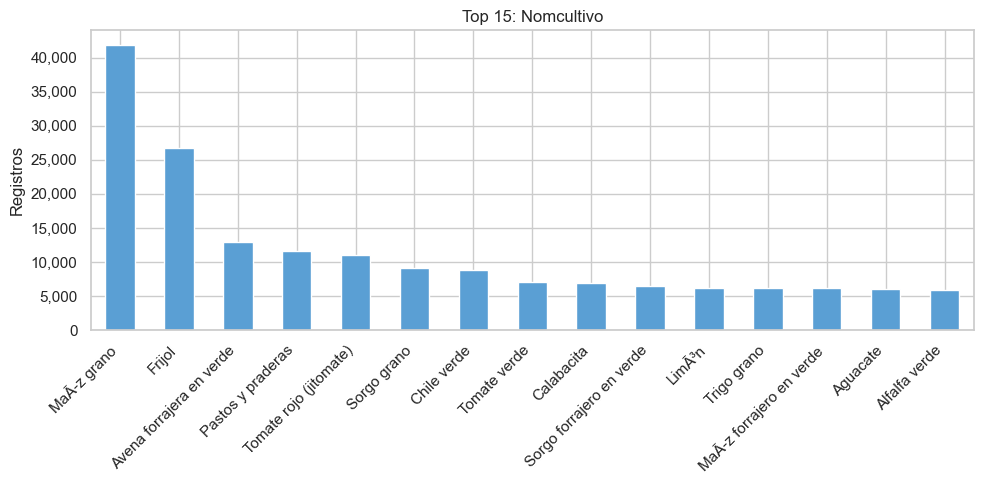


  Balance de ratio_siniestro por modalidad:
                 count    mean     std  min  25%  50%  75%  max
Nommodalidad                                                   
Riego         295553.0  0.0101  0.0848  0.0  0.0  0.0  0.0  1.0
Temporal      246286.0  0.0323  0.1471  0.0  0.0  0.0  0.0  1.0


In [9]:
eda.analisis_categoricas(top_n=15)

**Interpretación:**  
_(¿Hay desbalance entre cultivos o estados? ¿El maíz domina el dataset? ¿Las siembras de temporal son mucho más numerosas que las de riego? Esto afecta directamente al modelo supervisado: si hay desbalance fuerte, considera pesos de clase o SMOTE.)_

## 8. Serie de tiempo y análisis geográfico

Evolución anual del área sembrada, cosechada y siniestrada (2010-2024) desagregada por modalidad hídrica.  
Ranking de los estados con mayor área siniestrada acumulada.  
Requisito 8 (visualizaciones adicionales pertinentes al dominio).

  Figura guardada: figuras/serie_temporal_total.png


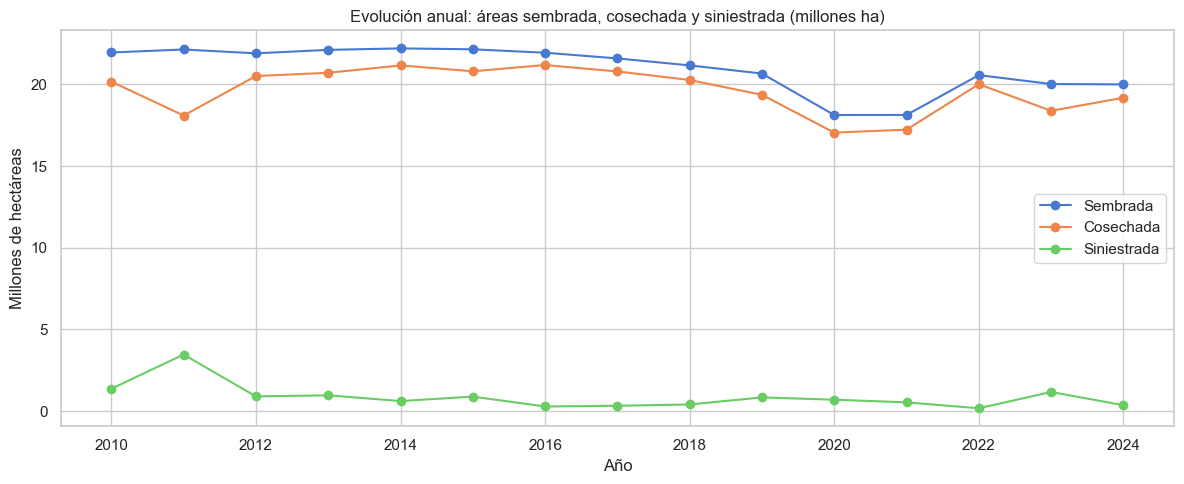

  Figura guardada: figuras/serie_temporal_modalidad.png


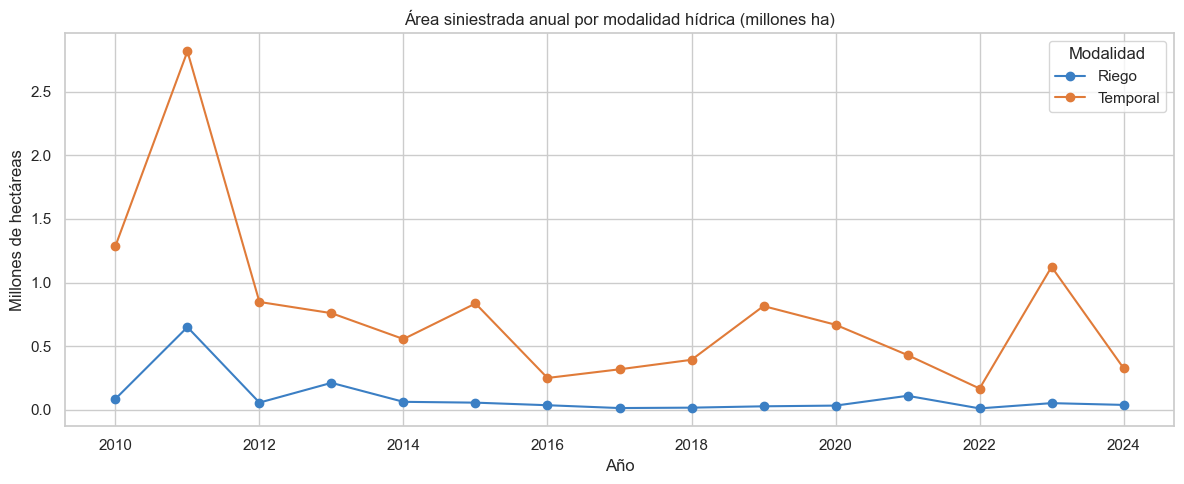

In [10]:
anual = eda.serie_temporal()

  Figura guardada: figuras/top_estados_siniestros.png


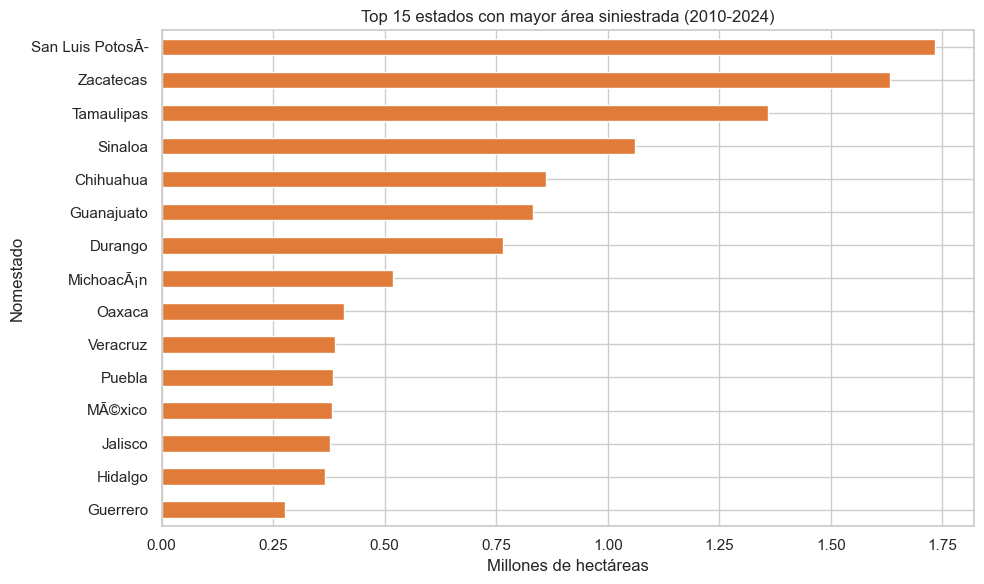

In [11]:
ranking_estados = eda.top_estados_siniestros(top_n=15)

**Interpretación:**  
_(¿Se observan años pico de siniestros? ¿Coinciden con eventos climáticos documentados (p.ej. sequía 2011, 2021)? ¿Qué estados concentran el daño y en qué modalidad? Esta información valida que el dataset captura la variabilidad climática real.)_

---
## Resumen ejecutivo del EDA

_(Completa esta sección al finalizar todo el EDA. Debe resumir en 5-8 oraciones las decisiones de preprocesamiento que tomarás para el modelo supervisado y el clustering, con base en lo observado arriba.)_

| Aspecto | Hallazgo | Acción para el modelado |
|---|---|---|
| Valores faltantes | ... | ... |
| Distribución de Siniestrada | ... | ... |
| Desbalance de clases | ... | ... |
| Outliers | ... | ... |
| Variables correlacionadas | ... | ... |